<a href="https://colab.research.google.com/github/maiap22/Portifolio/blob/main/Projeto_Rede_Neural_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [ ]:
# =============================================================================
# PROJETO: REDE NEURAL DO ZERO — WINE QUALITY DATASET
# Implementação manual com NumPy | Sem Scikit-Learn, TensorFlow ou Keras
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# =============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║         ETAPA 1 — SELEÇÃO E PREPARAÇÃO DA BASE DE DADOS                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# =============================================================================
# O Wine Quality Dataset possui 11 atributos físico-químicos do vinho tinto
# (acidez, açúcar, pH, álcool, etc.) e uma nota de qualidade (3 a 8).
# Transformamos o problema em CLASSIFICAÇÃO BINÁRIA:
#   • Classe 0 → "Ruim"  (qualidade <= 5)
#   • Classe 1 → "Bom"   (qualidade >= 6)
# =============================================================================

# ── 1.1 Carregamento dos dados ────────────────────────────────────────────
df = pd.read_csv('winequality-red.csv', sep=';')

print(f"\n[1.1] Dataset carregado: {df.shape[0]} amostras x {df.shape[1]} colunas")
print(f"     Colunas: {list(df.columns)}")
print(f"\n      Distribuição original de qualidade:")
for q, cnt in sorted(df["quality"].value_counts().items()):
    print(f"        Nota {q}: {cnt} amostras")

#Verificar valores
missing = df.isnull().sum().sum()
print(f"\n[1.2] Valores faltantes: {missing} {'Nenhum' if missing == 0 else '— Imputação pela mediana'}")
if missing > 0:
    df.fillna(df.median(), inplace=True)

#Criação do target binário
df["label"] = (df["quality"] >= 6).astype(int)

n_bom = df["label"].sum()
n_ruim = len(df) - n_bom
print(f"\n        Classe 1 — Bom  (qualidade ≥ 6): {n_bom} amostras  ({100*n_bom/len(df):.1f}%)")
print(f"        Classe 0 — Ruim (qualidade ≤ 5): {n_ruim} amostras ({100*n_ruim/len(df):.1f}%)")

#Normalização/Z-score
feature_cols = [c for c in df.columns if c not in ("quality", "label")]
X = df[feature_cols].values.astype(float)
y = df["label"].values.astype(float)

X_mean = X.mean(axis=0)
X_std =  X.std(axis=0) + 1e-8 #evitar divisão por zero
X_norm = (X - X_mean) / X_std

print(f"\n Features normalizadas (Z-score): shape {X_norm.shape}")
print(f"      Exemplo — média após normalização ≈ {X_norm.mean(axis=0).mean():.4f} (esperado ≈ 0)")

#Treino/Teste (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X_norm))
split = int(len(X_norm) * 0.8)

X_train, X_test = X_norm[indices[:split]], X_norm[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

print(f"\n Divisão treino/teste:")
print(f"        Treino: {X_train.shape[0]} amostras")
print(f"        Teste : {X_test.shape[0]} amostras")



[1.1] Dataset carregado: 1599 amostras x 12 colunas
     Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

      Distribuição original de qualidade:
        Nota 3: 10 amostras
        Nota 4: 53 amostras
        Nota 5: 681 amostras
        Nota 6: 638 amostras
        Nota 7: 199 amostras
        Nota 8: 18 amostras

[1.2] Valores faltantes: 0 Nenhum

        Classe 1 — Bom  (qualidade ≥ 6): 855 amostras  (53.5%)
        Classe 0 — Ruim (qualidade ≤ 5): 744 amostras (46.5%)

 Features normalizadas (Z-score): shape (1599, 11)
      Exemplo — média após normalização ≈ -0.0000 (esperado ≈ 0)

 Divisão treino/teste:
        Treino: 1279 amostras
        Teste : 320 amostras


In [ ]:
# =============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║       ETAPA 2 — IMPLEMENTAÇÃO DA REDE NEURAL                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# =============================================================================
# Arquitetura escolhida:
#   Entrada  → Camada Oculta 1 (64 neurônios, ReLU)
#            → Camada Oculta 2 (32 neurônios, ReLU)
#            → Saída (1 neurônio, Sigmoid) — classificação binária
#
# Algoritmo de otimização: Gradiente Descendente com Mini-Batches (SGD)
# Função de perda: Binary Cross-Entropy
# Regularização: L2 (weight decay)
# =============================================================================

#Funções de ativação

def relu(z):
    """ReLU: max(0, z) — usada nas camadas ocultas."""
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivada da ReLU: 1 se z > 0, senão 0."""
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid: 1 / (1 + e^-z) — usada na camada de saída """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    """Derivada da Sigmoid: σ(z) * (1 − σ(z))."""
    s = sigmoid(z)
    return s * (1 - s)

#Inicialização dos pesos (usando He Initialization)
def inicializar_pesos(camadas):
    params = {}
    for i in range(1, len(camadas)):
        n_in  = camadas[i - 1]
        n_out = camadas[i]
        # He initialization
        params[f"W{i}"] = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
        params[f"b{i}"] = np.zeros((1, n_out))
    return params

#Forward Propagation
def forward(X, params, n_camadas, dropout_rate=0.0, training=True):
  cache = {"A0": X}  #cache será reaproveitado para backpropagation
  A = X
  for i in range(1, n_camadas):
      W = params[f"W{i}"]
      b = params[f"b{i}"]
      Z = A @ W + b
      A = sigmoid(Z) if i == n_camadas - 1 else relu(Z)

      #Aplicar Dropout nas camadas ocultas:
      if training and dropout_rate > 0 and i < n_camadas -1:
        mask = (np.random.rand(*A.shape) > dropout_rate) / (1 - dropout_rate)
        A = A * mask
        cache[f"mask{i}"] = mask

      cache[f"Z{i}"] = Z
      cache[f"A{i}"] = A
  return A, cache

#Função de Perda: Binary Cross-Entropy e regularização L2
def calcular_loss(y_true, y_pred, params, n_camadas, lambda_l2=0.001):
    eps  = 1e-12   # evitar log(0)
    N    = len(y_true)
    bce  = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    # Regularização L2
    reg  = sum(np.sum(params[f"W{i}"] ** 2) for i in range(1, n_camadas))
    return bce + (lambda_l2 / (2 * N)) * reg

#Backpropagation
def backward(y_true, y_pred, cache, params, n_camadas, lambda_l2=0.001):
    grads = {}
    N     = len(y_true)
    y_t   = y_true.reshape(-1, 1)

    # Gradiente na saída (BCE + Sigmoid → derivada simplificada)
    dZ = (y_pred.reshape(-1, 1) - y_t) / N    # (N, 1)

    for i in range(n_camadas - 1, 0, -1):
        A_prev = cache[f"A{i-1}"]              # (N, n_in)
        W      = params[f"W{i}"]

        grads[f"dW{i}"] = A_prev.T @ dZ + (lambda_l2 / N) * W
        grads[f"db{i}"] = dZ.mean(axis=0, keepdims=True)

        if i > 1:   # Propaga o gradiente para a camada anterior
            dA = dZ @ W.T
            if f"mask{i-1}" in cache:
                dA = dA * cache[f"mask{i-1}"]
            dZ = dA * relu_deriv(cache[f"Z{i-1}"])

    return grads

#Atualização dos pesos(SGD)
def atualizar_pesos(params, grads, n_camadas, lr):
    for i in range(1, n_camadas):
        params[f"W{i}"] -= lr * grads[f"dW{i}"]
        params[f"b{i}"] -= lr * grads[f"db{i}"]
    return params


In [ ]:
# =============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║          ETAPA 3 — TREINAMENTO DA REDE NEURAL                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# =============================================================================
# O treinamento ocorre em épocas. Em cada época:
#   1. Os dados de treino são embaralhados e divididos em mini-batches.
#   2. Para cada mini-batch: forward → loss → backward → update.
#   3. Registramos a loss de treino e teste ao longo das épocas.
# =============================================================================

#Hiperparâmetros
CAMADAS    = [X_train.shape[1], 128, 64, 32, 1]   # [11, 64, 32, 1]
N_CAMADAS  = len(CAMADAS)
EPOCAS     = 1500
LR         = 0.01        # Learning Rate
BATCH_SIZE = 32
LAMBDA_L2  = 0.001       # Regularização L2
DROPOUT_RATE = 0.3        # Após os primeiros teste, verificou-se Overfitting no modelo. Foi adicionado um Dropout para corrigir o problema.
THRESHOLD = 0.48

print(f"\n  Arquitetura : {' → '.join(map(str, CAMADAS))}")
print(f"  Épocas      : {EPOCAS}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  L2 lambda   : {LAMBDA_L2}")
print()

np.random.seed(42)
params = inicializar_pesos(CAMADAS)

historico_loss_treino = []
historico_loss_teste  = []
historico_acc_treino  = []
historico_acc_teste   = []

for epoca in range(1, EPOCAS + 1):

    # -- Embaralhamento dos dados
    perm     = np.random.permutation(len(X_train))
    X_shuf   = X_train[perm]
    y_shuf   = y_train[perm]

    # -- Mini-batch training
    for start in range(0, len(X_shuf), BATCH_SIZE):
        X_batch = X_shuf[start : start + BATCH_SIZE]
        y_batch = y_shuf[start : start + BATCH_SIZE]

        # Forward
        y_pred_batch, cache = forward(X_batch, params, N_CAMADAS, dropout_rate=DROPOUT_RATE, training=True)
        y_pred_batch = y_pred_batch.flatten()

        # Backward
        grads = backward(y_batch, y_pred_batch, cache, params, N_CAMADAS, LAMBDA_L2)

        # Update
        params = atualizar_pesos(params, grads, N_CAMADAS, LR)

    # -- Avaliação ao final da época
    y_pred_train, _ = forward(X_train, params, N_CAMADAS, training=False) # _ = descartar cache
    y_pred_test,  _ = forward(X_test,  params, N_CAMADAS, training=False)

    y_pred_train = y_pred_train.flatten()
    y_pred_test  = y_pred_test.flatten()

    loss_treino = calcular_loss(y_train, y_pred_train, params, N_CAMADAS, LAMBDA_L2)
    loss_teste  = calcular_loss(y_test,  y_pred_test,  params, N_CAMADAS, LAMBDA_L2)

    acc_treino = np.mean((y_pred_train >= THRESHOLD).astype(int) == y_train)
    acc_teste  = np.mean((y_pred_test  >= THRESHOLD).astype(int) == y_test)

    historico_loss_treino.append(loss_treino)
    historico_loss_teste.append(loss_teste)
    historico_acc_treino.append(acc_treino)
    historico_acc_teste.append(acc_teste)

    # Log a cada 150 épocas
    if epoca % 150 == 0 or epoca == 1:
        print(f"  Época {epoca:>3} | Loss Treino: {loss_treino:.4f} | Loss Teste: {loss_teste:.4f} "
              f"| Acc Treino: {acc_treino:.4f} | Acc Teste: {acc_teste:.4f}")


  Arquitetura : 11 → 128 → 64 → 32 → 1
  Épocas      : 1500
  Batch size  : 32
  Learning rate: 0.01
  L2 lambda   : 0.001

  Época   1 | Loss Treino: 0.6484 | Loss Teste: 0.6439 | Acc Treino: 0.6224 | Acc Teste: 0.6062
  Época 150 | Loss Treino: 0.5050 | Loss Teste: 0.4727 | Acc Treino: 0.7592 | Acc Teste: 0.8313
  Época 300 | Loss Treino: 0.4764 | Loss Teste: 0.4571 | Acc Treino: 0.7756 | Acc Teste: 0.8281
  Época 450 | Loss Treino: 0.4573 | Loss Teste: 0.4641 | Acc Treino: 0.7866 | Acc Teste: 0.8156
  Época 600 | Loss Treino: 0.4373 | Loss Teste: 0.4665 | Acc Treino: 0.8022 | Acc Teste: 0.8187
  Época 750 | Loss Treino: 0.4176 | Loss Teste: 0.4620 | Acc Treino: 0.8194 | Acc Teste: 0.8406
  Época 900 | Loss Treino: 0.4011 | Loss Teste: 0.4596 | Acc Treino: 0.8249 | Acc Teste: 0.8406
  Época 1050 | Loss Treino: 0.3826 | Loss Teste: 0.4615 | Acc Treino: 0.8397 | Acc Teste: 0.8438
  Época 1200 | Loss Treino: 0.3657 | Loss Teste: 0.4565 | Acc Treino: 0.8491 | Acc Teste: 0.8438
  Época 1

In [ ]:
# =============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║          ETAPA 4 — AVALIAÇÃO DO DESEMPENHO                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# =============================================================================
# Calculamos manualmente (sem Scikit-Learn) as métricas:
#   • Acurácia  : (TP + TN) / Total
#   • Precisão  : TP / (TP + FP)
#   • Recall    : TP / (TP + FN)
#   • F1-Score  : 2 * (Precisão * Recall) / (Precisão + Recall)
#   • Matriz de Confusão
# =============================================================================

y_pred_final, _ = forward(X_test, params, N_CAMADAS, training=False)
y_pred_classes  = (y_pred_final.flatten() >= THRESHOLD).astype(int)

def calcular_metricas(y_true, y_pred):
    """Calcula Acurácia, Precisão, Recall, F1-Score e Matriz de Confusão."""
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    acuracia  = (TP + TN) / len(y_true)
    precisao  = TP / (TP + FP + 1e-12)
    recall    = TP / (TP + FN + 1e-12)
    f1        = 2 * (precisao * recall) / (precisao + recall + 1e-12)

    conf_matrix = np.array([[TN, FP],
                             [FN, TP]])
    return acuracia, precisao, recall, f1, conf_matrix

acuracia, precisao, recall, f1, conf_matrix = calcular_metricas(y_test, y_pred_classes)

print(f"\n  Acurácia  : {acuracia:.4f}  ({acuracia*100:.2f}%)")
print(f"  Precisão  : {precisao:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"\n  Matriz de Confusão:")
print(f"               Pred: Ruim   Pred: Bom")
print(f"  Real: Ruim  |  {conf_matrix[0,0]:>5}   |   {conf_matrix[0,1]:>5}  |")
print(f"  Real: Bom   |  {conf_matrix[1,0]:>5}   |   {conf_matrix[1,1]:>5}  |")


  Acurácia  : 0.8438  (84.38%)
  Precisão  : 0.8533
  Recall    : 0.8722
  F1-Score  : 0.8626

  Matriz de Confusão:
               Pred: Ruim   Pred: Bom
  Real: Ruim  |    113   |      27  |
  Real: Bom   |     23   |     157  |



[5] Gerando gráficos...
  Gráfico salvo em: resultados_rede_neural.png

  TREINAMENTO CONCLUÍDO!
  Acurácia final no teste: 84.38%


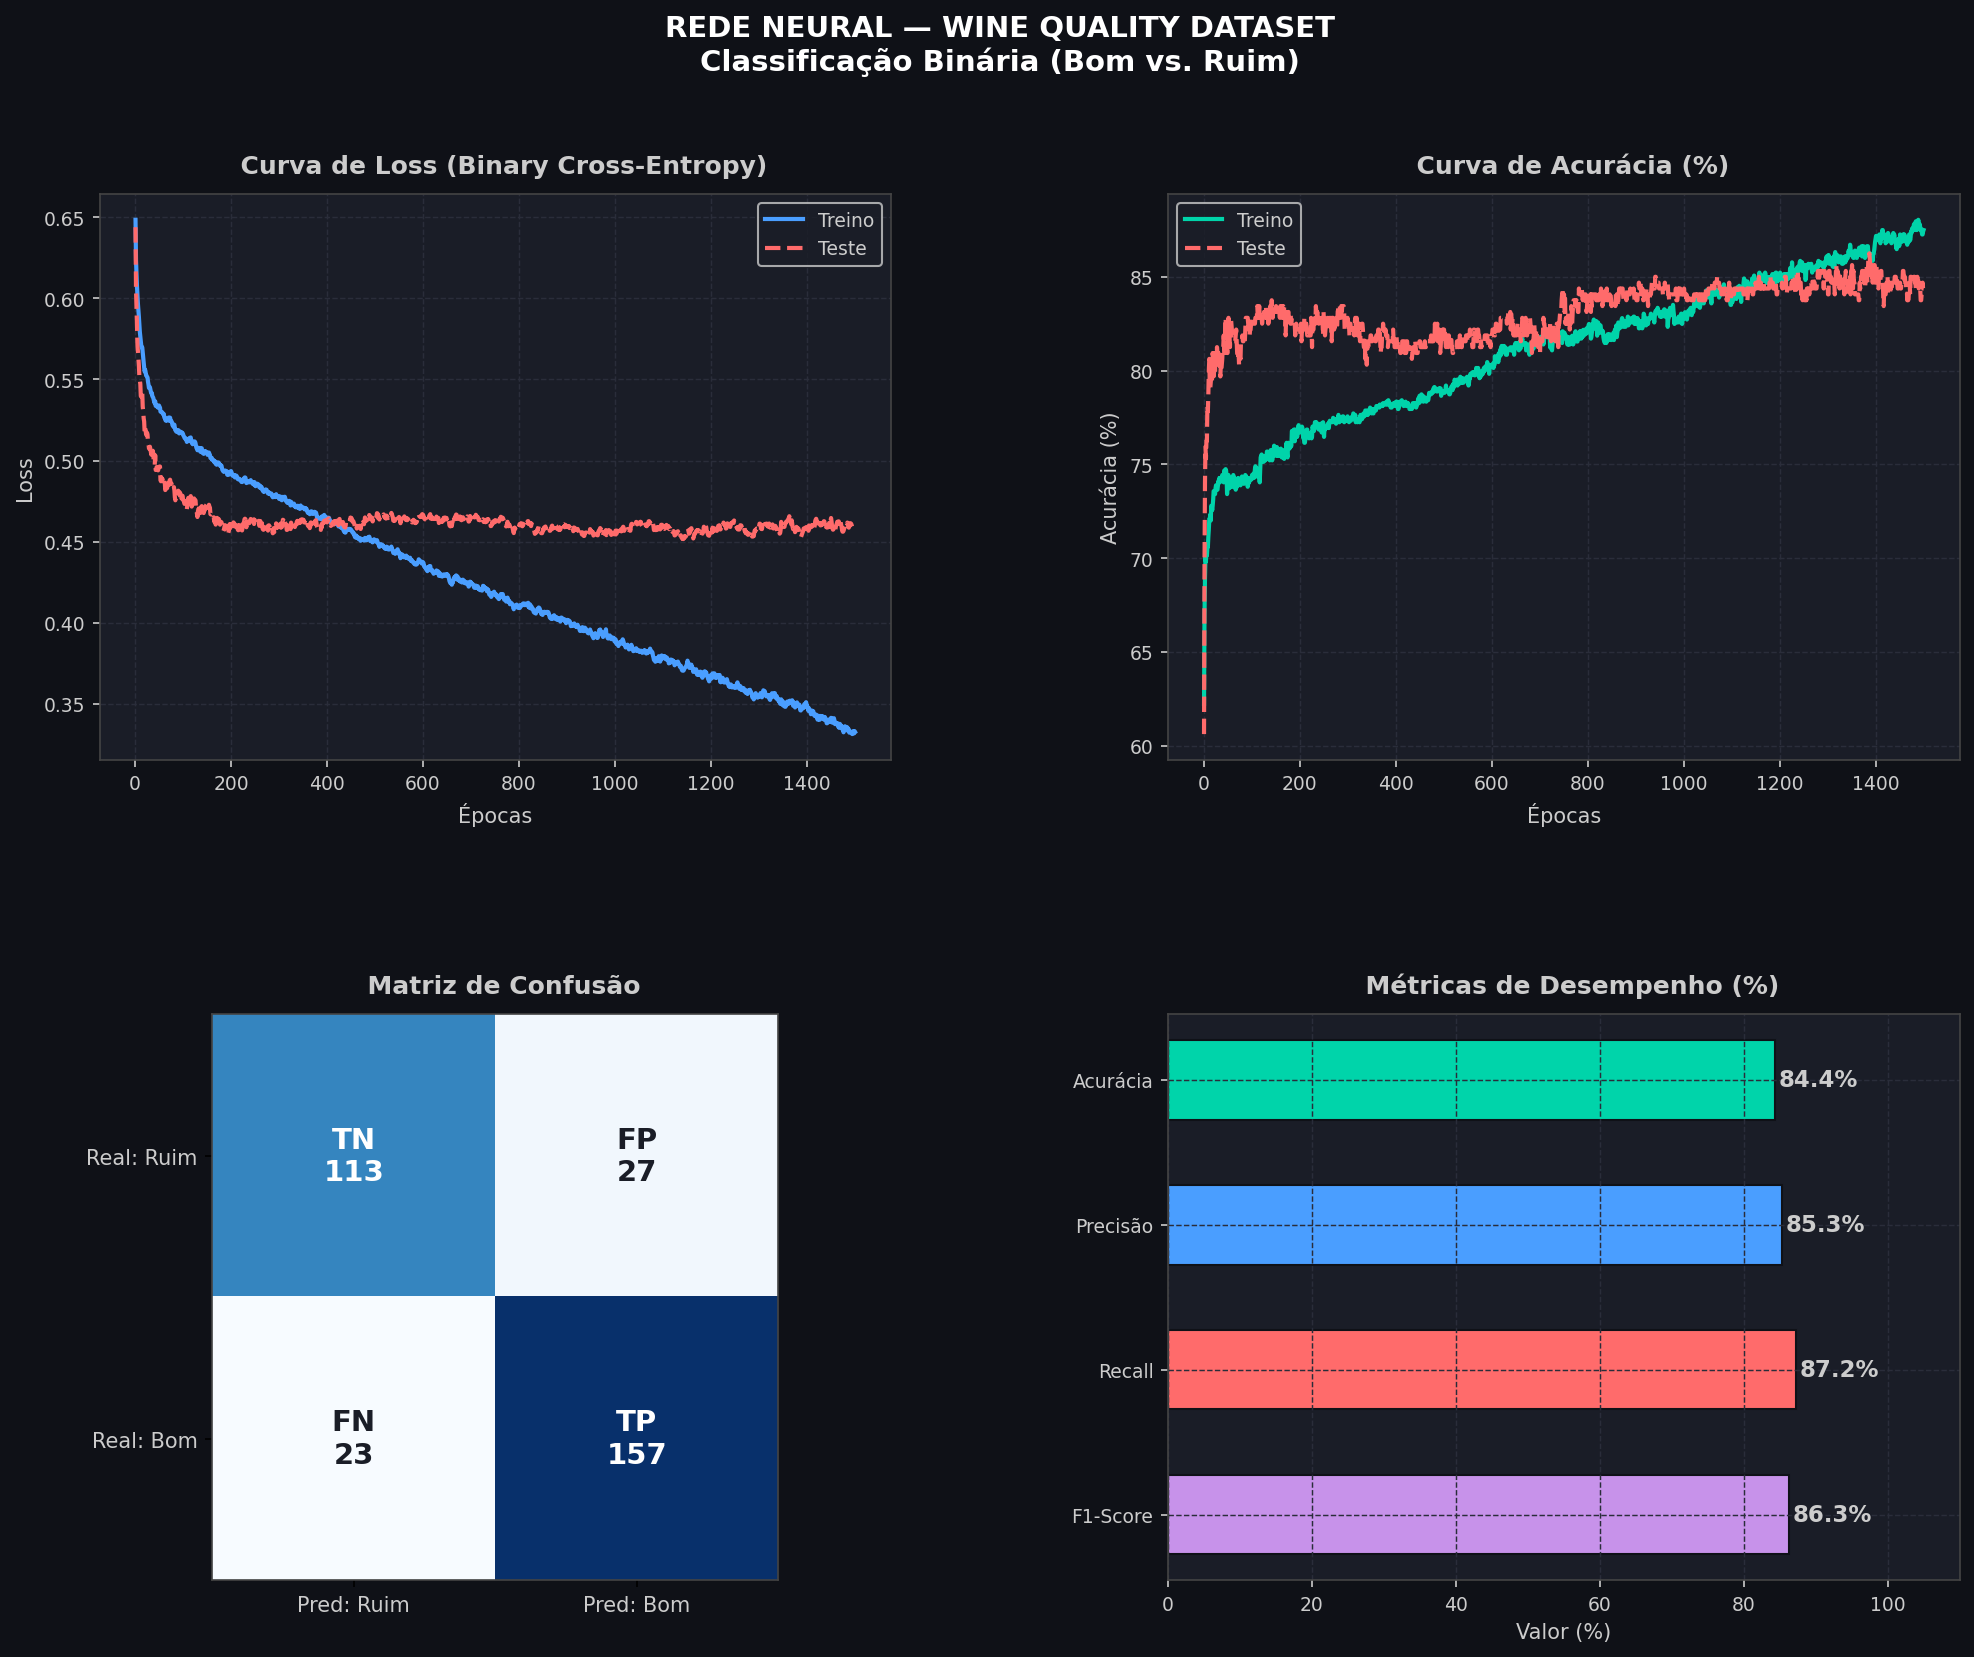

In [ ]:
# =============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║          ETAPA 5 — GERAÇÃO DOS GRÁFICOS                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# =============================================================================

print("\n[5] Gerando gráficos...")

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

VERDE   = "#00d4aa"
LARANJA = "#ff6b6b"
AZUL    = "#4a9eff"
CINZA   = "#cccccc"
FUNDO   = "#1a1d27"

def estilo_ax(ax, titulo):
    ax.set_facecolor(FUNDO)
    ax.set_title(titulo, color=CINZA, fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(colors=CINZA, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.xaxis.label.set_color(CINZA)
    ax.yaxis.label.set_color(CINZA)
    ax.grid(True, color="#2a2d3a", linewidth=0.7, linestyle="--")

epocas_x = range(1, EPOCAS + 1)

# ── Gráfico 1: Curva de Loss ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epocas_x, historico_loss_treino, color=AZUL,   lw=2, label="Treino")
ax1.plot(epocas_x, historico_loss_teste,  color=LARANJA, lw=2, label="Teste", linestyle="--")
estilo_ax(ax1, "  Curva de Loss (Binary Cross-Entropy)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend(facecolor="#1a1d27", labelcolor=CINZA, fontsize=9)

# ── Gráfico 2: Curva de Acurácia ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epocas_x, [a * 100 for a in historico_acc_treino], color=VERDE,   lw=2, label="Treino")
ax2.plot(epocas_x, [a * 100 for a in historico_acc_teste],  color=LARANJA, lw=2, label="Teste", linestyle="--")
estilo_ax(ax2, "  Curva de Acurácia (%)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Acurácia (%)")
ax2.legend(facecolor="#1a1d27", labelcolor=CINZA, fontsize=9)

# ── Gráfico 3: Matriz de Confusão ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(FUNDO)
im   = ax3.imshow(conf_matrix, cmap="Blues")
lbls = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
                 valor = conf_matrix[i, j]
                 cor_texto = "white" if valor > conf_matrix.max() / 2 else "#1a1d27"
                 ax3.text(j, i,
                          f"{lbls[i][j]}\n{valor}",
                          ha="center", va="center",
                          color=cor_texto, fontsize=14, fontweight="bold")
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(["Pred: Ruim", "Pred: Bom"], color=CINZA)
ax3.set_yticklabels(["Real: Ruim", "Real: Bom"], color=CINZA)
ax3.set_title("  Matriz de Confusão", color=CINZA, fontsize=12, fontweight="bold", pad=10)
for spine in ax3.spines.values():
    spine.set_edgecolor("#444")

# ── Gráfico 4: Barras das Métricas ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(FUNDO)
metricas_nomes  = ["Acurácia", "Precisão", "Recall", "F1-Score"]
metricas_vals   = [acuracia, precisao, recall, f1]
cores_barras    = [VERDE, AZUL, LARANJA, "#c792ea"]
bars = ax4.barh(metricas_nomes, [v * 100 for v in metricas_vals],
                color=cores_barras, height=0.55, edgecolor="#0f1117")
for bar, val in zip(bars, metricas_vals):
    ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val*100:.1f}%", va="center", color=CINZA, fontsize=11, fontweight="bold")
ax4.set_xlim(0, 110)
estilo_ax(ax4, "  Métricas de Desempenho (%)")
ax4.set_xlabel("Valor (%)")
ax4.invert_yaxis()

# ── Título global ─────────────────────────────────────────────────────────
fig.suptitle("REDE NEURAL — WINE QUALITY DATASET\nClassificação Binária (Bom vs. Ruim)",
             color="white", fontsize=14, fontweight="bold", y=0.98)

plt.savefig("resultados_rede_neural.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())

plt.close()
print("  Gráfico salvo em: resultados_rede_neural.png")
print("\n" + "=" * 65)
print("  TREINAMENTO CONCLUÍDO!")
print(f"  Acurácia final no teste: {acuracia*100:.2f}%")
print("=" * 65)

from IPython.display import Image
Image("resultados_rede_neural.png")